In [165]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix, roc_auc_score,
    roc_curve, ConfusionMatrixDisplay, average_precision_score
)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'

import warnings
warnings.filterwarnings('ignore')


In [166]:
FILE = 'Case_Study_Data_Science_Intern.xlsx'

loans    = pd.read_excel(FILE, sheet_name='Loan Data')
payments = pd.read_excel(FILE, sheet_name='Payment History')
schufa   = pd.read_excel(FILE, sheet_name='Schufa PD 12 Distribution')

# Exploratory Data Analysis

In [52]:
print(f'Loan Data      : {loans.shape}')
print(f'Payment History: {payments.shape}')
print(f'SCHUFA Table   : {schufa.shape}')

Loan Data      : (1000, 33)
Payment History: (12000, 6)
SCHUFA Table   : (15, 4)


In [53]:
loans.head(5)

,customer_id,age,annual_income,employment_years,property_ownership,property_value,state,loan_amount,loan_term_months,interest_rate,...,loan_to_income_ratio,debt_to_income,payment_to_income,loan_to_value,savings_coverage_ratio,avg_days_late,max_days_late,avg_payment,payment_std,default_flag
0,1,49,120532,NaN,Mortgage,174979.0,NRW,24977,60,5.964251,...,0.207223,0.094864,0.048033,0.142743,0.447911,3.083333,30,442.255282,139.274294,0
1,2,43,95065,9.0,Mortgage,274117.0,NRW,20735,120,6.109136,...,0.218114,0.061582,0.029202,0.075643,0.730376,0.500000,2,231.339042,0.000000,0
2,3,51,61686,6.0,Own,205760.0,Bavaria,22247,180,6.072445,...,0.360649,0.070580,0.036690,0.108121,0.815344,1.500000,10,188.604676,0.000000,0
3,4,60,43327,8.0,Mortgage,138003.0,Bavaria,22003,120,5.897047,...,0.507836,0.364982,0.067342,0.159439,0.679434,2.250000,10,233.011456,35.094581,0
4,5,42,84890,0.0,Mortgage,NaN,Lower Saxony,17160,180,6.431666,...,0.202144,0.137663,0.021040,0.095127,0.927007,3.500000,30,136.434970,42.965873,0


In [57]:
loans.dtypes

,0
customer_id,int64
age,int64
annual_income,int64
employment_years,float64
property_ownership,object
property_value,float64
state,object
loan_amount,int64
loan_term_months,int64
interest_rate,float64


In [58]:
loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   customer_id                  1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   annual_income                1000 non-null   int64  
 3   employment_years             945 non-null    float64
 4   property_ownership           1000 non-null   object 
 5   property_value               952 non-null    float64
 6   state                        1000 non-null   object 
 7   loan_amount                  1000 non-null   int64  
 8   loan_term_months             1000 non-null   int64  
 9   interest_rate                1000 non-null   float64
 10  schufa_score                 1000 non-null   int64  
 11  num_credit_lines             1000 non-null   int64  
 12  credit_utilization           948 non-null    float64
 13  previous_defaults  

In [67]:
missing = loans.isnull().sum()
missing = missing[missing > 0]

missing = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": (missing / len(loans) * 100).round(1),
})

print(missing)

                    Missing Count  Missing %
employment_years               55        5.5
property_value                 48        4.8
credit_utilization             52        5.2


In [72]:
df = loans.copy()

cols_to_fill = ["employment_years", "property_value", "credit_utilization"]

for col in cols_to_fill:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)
    missing_after = df[col].isnull().sum()

    print(f"{col} | median = {median_value:8.2f} | Missing: {missing_after}")

employment_years | median =     9.00 | Missing: 0
property_value | median = 160960.00 | Missing: 0
credit_utilization | median =     0.39 | Missing: 0


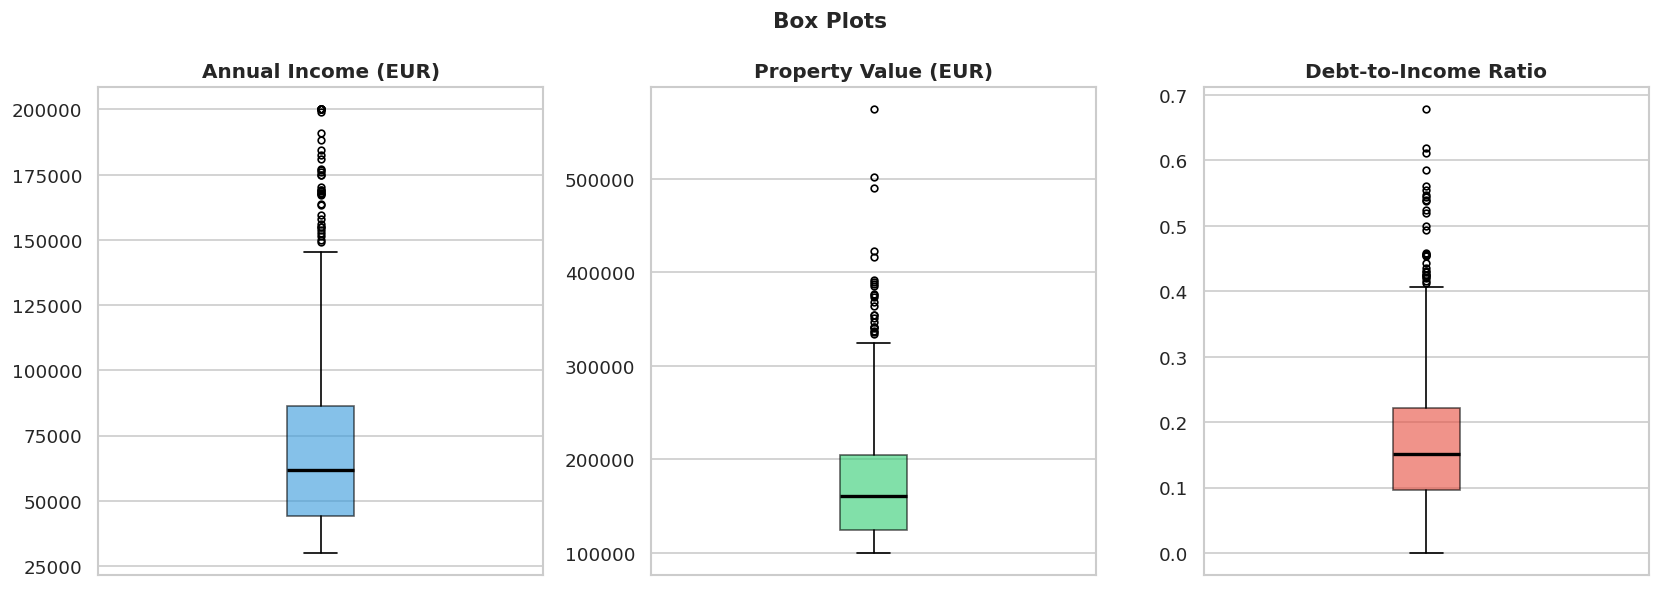

In [82]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(
    "Box Plots",
    fontsize=13,
    fontweight="bold"
)

columns = ["annual_income", "property_value", "debt_to_income"]
titles = ["Annual Income (EUR)", "Property Value (EUR)", "Debt-to-Income Ratio"]

for ax, col, title, color in zip(axes, columns, titles, colors):
    data = df[col].dropna()

    ax.boxplot(
        data,
        patch_artist=True,
        boxprops=dict(facecolor=color, alpha=0.6),
        medianprops=dict(color="black", linewidth=2),
        flierprops=dict(marker="o", color="red", markersize=4),
    )

    ax.set_title(title, fontweight="bold")
    ax.set_xticks([])

plt.tight_layout()
plt.show()


In [88]:
def count_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = ((df[col] > upper_bound) | (df[col] < lower_bound)).sum()

    return outlier_count, lower_bound, upper_bound


columns_to_check = [
    "annual_income",
    "property_value",
    "debt_to_income",
    "loan_amount",
    "interest_rate",
]

print("Column | Outliers | Normal Range")

for col in columns_to_check:
    count, low, high = count_outliers(df, col)
    print(f"{col} | {count} | {low:.0f} to {high:.0f}")

Column | Outliers | Normal Range
annual_income | 40 | -18758 to 149177
property_value | 24 | 4551 to 324802
debt_to_income | 30 | -0 to 0
loan_amount | 4 | 2439 to 47142
interest_rate | 3 | 3 to 8


In [92]:
cols_to_cap = ["annual_income", "property_value", "debt_to_income"]

for col in cols_to_cap:
    cap = df[col].quantile(0.99)
    values_to_cap = (df[col] > cap).sum()

    df[col] = df[col].clip(upper=cap)

    print(f"{col} | Capped {values_to_cap} values at {cap:.0f}")

annual_income | Capped 10 values at 190930
property_value | Capped 10 values at 375975
debt_to_income | Capped 10 values at 1


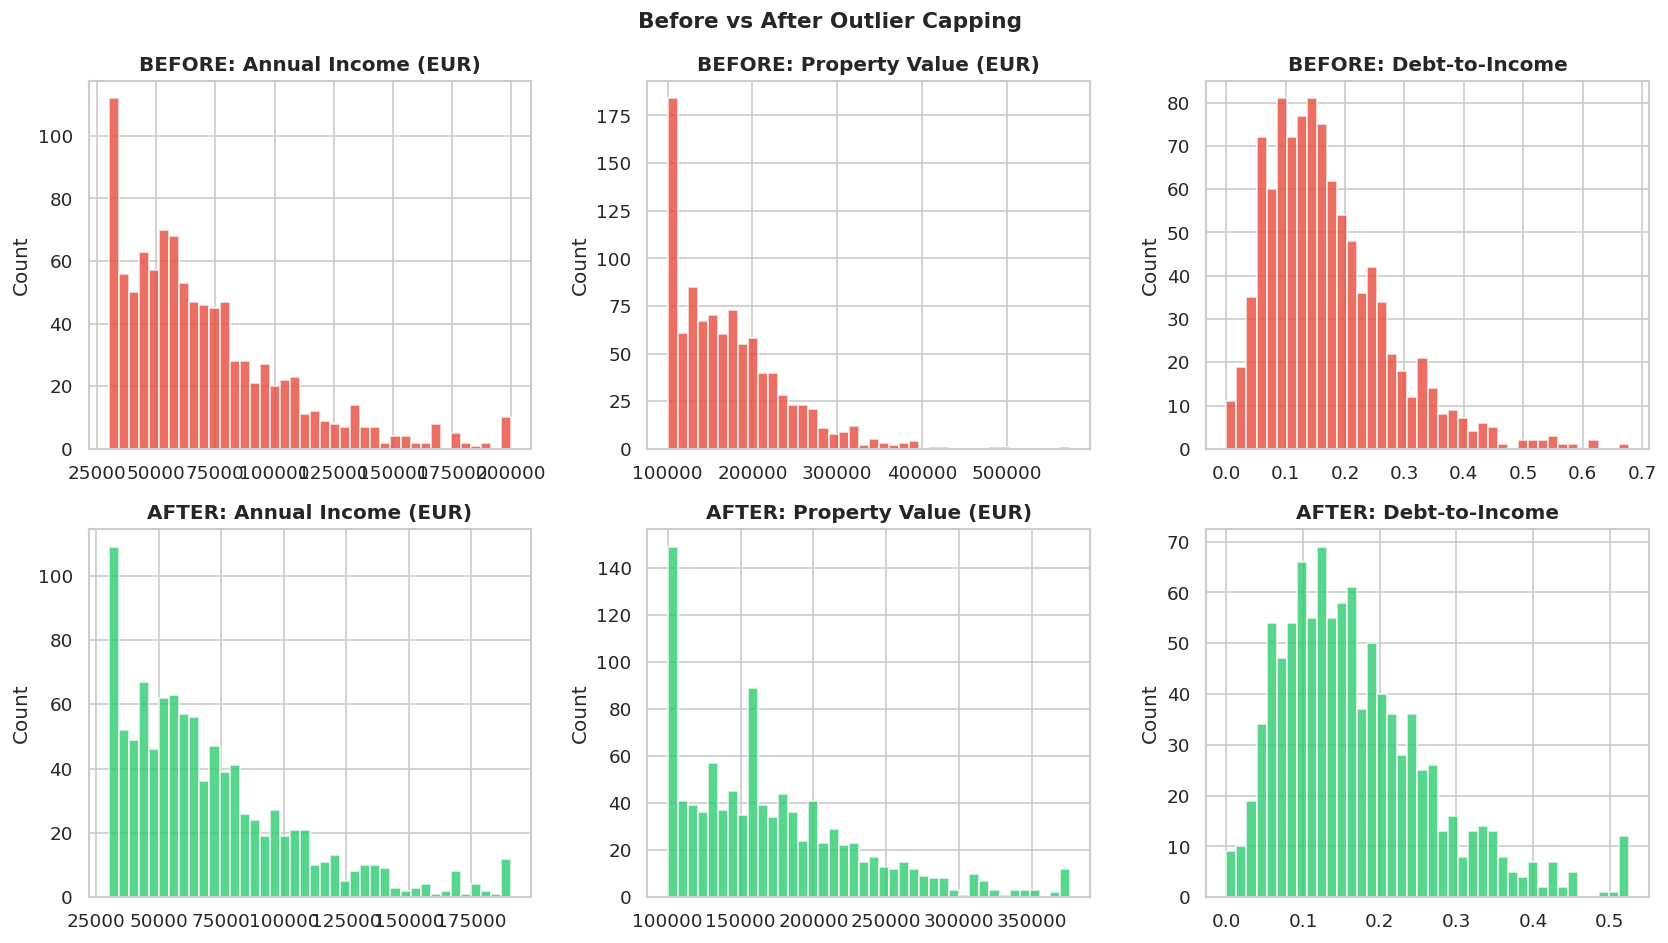

The long tail on the right side is now gone.
Distribution looks cleaner and more representative.


In [93]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Before vs After Outlier Capping', fontsize=13, fontweight='bold')

titles = ['Annual Income (EUR)', 'Property Value (EUR)', 'Debt-to-Income']

for i, (col, title) in enumerate(zip(cols_to_cap, titles)):

    axes[0, i].hist(loans[col].dropna(), bins=40, color='#e74c3c', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'BEFORE: {title}', fontweight='bold')
    axes[0, i].set_ylabel('Count')


    axes[1, i].hist(df[col], bins=40, color='#2ecc71', edgecolor='white', alpha=0.8)
    axes[1, i].set_title(f'AFTER: {title}', fontweight='bold')
    axes[1, i].set_ylabel('Count')

plt.tight_layout()
plt.show()



In [94]:
# Quick check: are there still outliers after capping?
print('Outlier count AFTER capping:')
print()
for col in cols_to_cap:
    n, _, _ = count_outliers(df, col)
    print(f'{col:<22} : {n} outliers remaining')

print()
print('Note: A small number may remain because capping at 99th pct')
print('moves the Q3/IQR boundary slightly. These are acceptable edge cases.')

Outlier count AFTER capping:

annual_income          : 40 outliers remaining
property_value         : 24 outliers remaining
debt_to_income         : 30 outliers remaining

Note: A small number may remain because capping at 99th pct
moves the Q3/IQR boundary slightly. These are acceptable edge cases.


### Summary Statistics

In [98]:
print("ANNUAL INCOME")

mean_income = df["annual_income"].mean()
median_income = df["annual_income"].median()
std_income = df["annual_income"].std()
min_income = df["annual_income"].min()
max_income = df["annual_income"].max()

print(f"Mean: EUR {mean_income:,.0f}")
print(f"Median: EUR {median_income:,.0f}")
print(f"Std Dev: EUR {std_income:,.0f}")
print(f"Range: EUR {min_income:,.0f} - EUR {max_income:,.0f}")


ANNUAL INCOME
Mean: EUR 70,221
Median: EUR 61,792
Std Dev: EUR 34,625
Range: EUR 30,000 - EUR 190,930


In [100]:
print("LOAN AMOUNT")

mean_loan = df["loan_amount"].mean()
median_loan = df["loan_amount"].median()
min_loan = df["loan_amount"].min()
max_loan = df["loan_amount"].max()
std_loan = df["loan_amount"].std()

print(f"Mean: EUR {mean_loan:,.0f}")
print(f"Median: EUR {median_loan:,.0f}")
print(f"Range: EUR {min_loan:,.0f} - EUR {max_loan:,.0f}")
print(f"Std Dev: EUR {std_loan:,.0f}")


LOAN AMOUNT
Mean: EUR 24,802
Median: EUR 24,606
Range: EUR 10,000 - EUR 49,786
Std Dev: EUR 7,900


In [104]:
print("LOAN TERM (TENOR)")

term_counts = df["loan_term_months"].value_counts().sort_index()

for term, count in term_counts.items():
    years = term // 12
    pct = count / len(df) * 100

    print(f"{term:4d} months ({years:2d} years) : {count:4d} customers ({pct:4.1f}%)")


LOAN TERM (TENOR)
  60 months ( 5 years) :  290 customers (29.0%)
 120 months (10 years) :  523 customers (52.3%)
 180 months (15 years) :  187 customers (18.7%)


In [106]:
print("INTEREST RATE")

mean_rate = df["interest_rate"].mean()
median_rate = df["interest_rate"].median()
min_rate = df["interest_rate"].min()
max_rate = df["interest_rate"].max()
std_rate = df["interest_rate"].std()

print(f"Average: {mean_rate:.2f}%")
print(f"Median : {median_rate:.2f}%")
print(f"Range  : {min_rate:.1f}% - {max_rate:.1f}%")
print(f"Std Dev: {std_rate:.2f}%")


INTEREST RATE
Average: 5.52%
Median : 5.49%
Range  : 3.0% - 8.9%
Std Dev: 1.03%


In [108]:
print("DEBT-TO-INCOME RATIO (DTI)")
print("DTI = total monthly debt / monthly income\n")

dti_mean = df["debt_to_income"].mean() * 100
dti_median = df["debt_to_income"].median() * 100
dti_max = df["debt_to_income"].max() * 100
dti_min = df["debt_to_income"].min() * 100

print(f"Average: {dti_mean:.1f}%")
print(f"Median : {dti_median:.1f}%")
print(f"Max    : {dti_max:.1f}% (after capping)")
print(f"Min    : {dti_min:.1f}%")

print()
print("Risk thresholds:")
print("< 20%  → Low risk")
print("20–35% → Medium risk")
print("> 35%  → High risk\n")

low_dti = (df["debt_to_income"] < 0.20).sum()
mid_dti = ((df["debt_to_income"] >= 0.20) & (df["debt_to_income"] < 0.35)).sum()
high_dti = (df["debt_to_income"] >= 0.35).sum()

n = len(df)

print(f"DTI < 20%  : {low_dti} ({low_dti/n*100:.1f}%)")
print(f"DTI 20-35%: {mid_dti} ({mid_dti/n*100:.1f}%)")
print(f"DTI > 35%  : {high_dti} ({high_dti/n*100:.1f}%)")

DEBT-TO-INCOME RATIO (DTI)
DTI = total monthly debt / monthly income

Average: 16.9%
Median : 15.1%
Max    : 52.5% (after capping)
Min    : 0.0%

Risk thresholds:
< 20%  → Low risk
20–35% → Medium risk
> 35%  → High risk

DTI < 20%  : 686 (68.6%)
DTI 20-35%: 256 (25.6%)
DTI > 35%  : 58 (5.8%)


In [112]:
print("SCHUFA CREDIT SCORE")

score_mean = df["schufa_score"].mean()
score_median = df["schufa_score"].median()
score_min = df["schufa_score"].min()
score_max = df["schufa_score"].max()

print(f"Average: {score_mean:.0f}")
print(f"Median : {score_median:.0f}")
print(f"Range  : {score_min:.0f} - {score_max:.0f}")

print()
print("Score interpretation:")
print("9000+   → Good borrower")
print("8000-9000 → Fair borrower")
print("< 8000  → Risky borrower")

risky = (df["schufa_score"] < 8000).sum()
n = len(df)


SCHUFA CREDIT SCORE
Average: 9200
Median : 9211
Range  : 7939 - 9999

Score interpretation:
9000+   → Good borrower
8000-9000 → Fair borrower
< 8000  → Risky borrower


In [115]:
payments["payment_ratio"] = payments["amount_paid"] / payments["amount_due"]


total_records = len(payments)
months_history = len(payments) // 1000

avg_due = payments["amount_due"].mean()
avg_paid = payments["amount_paid"].mean()
avg_ratio = payments["payment_ratio"].mean()

print(f"Total payment records   : {total_records:,}")
print(f"Months of history       : {months_history}")
print(f"Avg amount due per month: EUR {avg_due:,.2f}")
print(f"Avg amount paid         : EUR {avg_paid:,.2f}")
print(f"Avg payment completeness: {avg_ratio:.3f} (1.0 = full payment)\n")

print("Days late breakdown:")

on_time = (payments["days_late"] == 0).sum()
late_30 = ((payments["days_late"] > 0) & (payments["days_late"] <= 30)).sum()
late_60 = (payments["days_late"] > 30).sum()

n = len(payments)

print(f"On time (0 days late) : {on_time:,} ({on_time/n*100:.1f}%)")
print(f"1-30 days late        : {late_30:,} ({late_30/n*100:.1f}%)")
print(f"31+ days late         : {late_60:,} ({late_60/n*100:.1f}%)")


Total payment records   : 12,000
Months of history       : 12
Avg amount due per month: EUR 317.19
Avg amount paid         : EUR 305.95
Avg payment completeness: 0.965 (1.0 = full payment)

Days late breakdown:
On time (0 days late) : 8,499 (70.8%)
1-30 days late        : 3,375 (28.1%)
31+ days late         : 126 (1.1%)


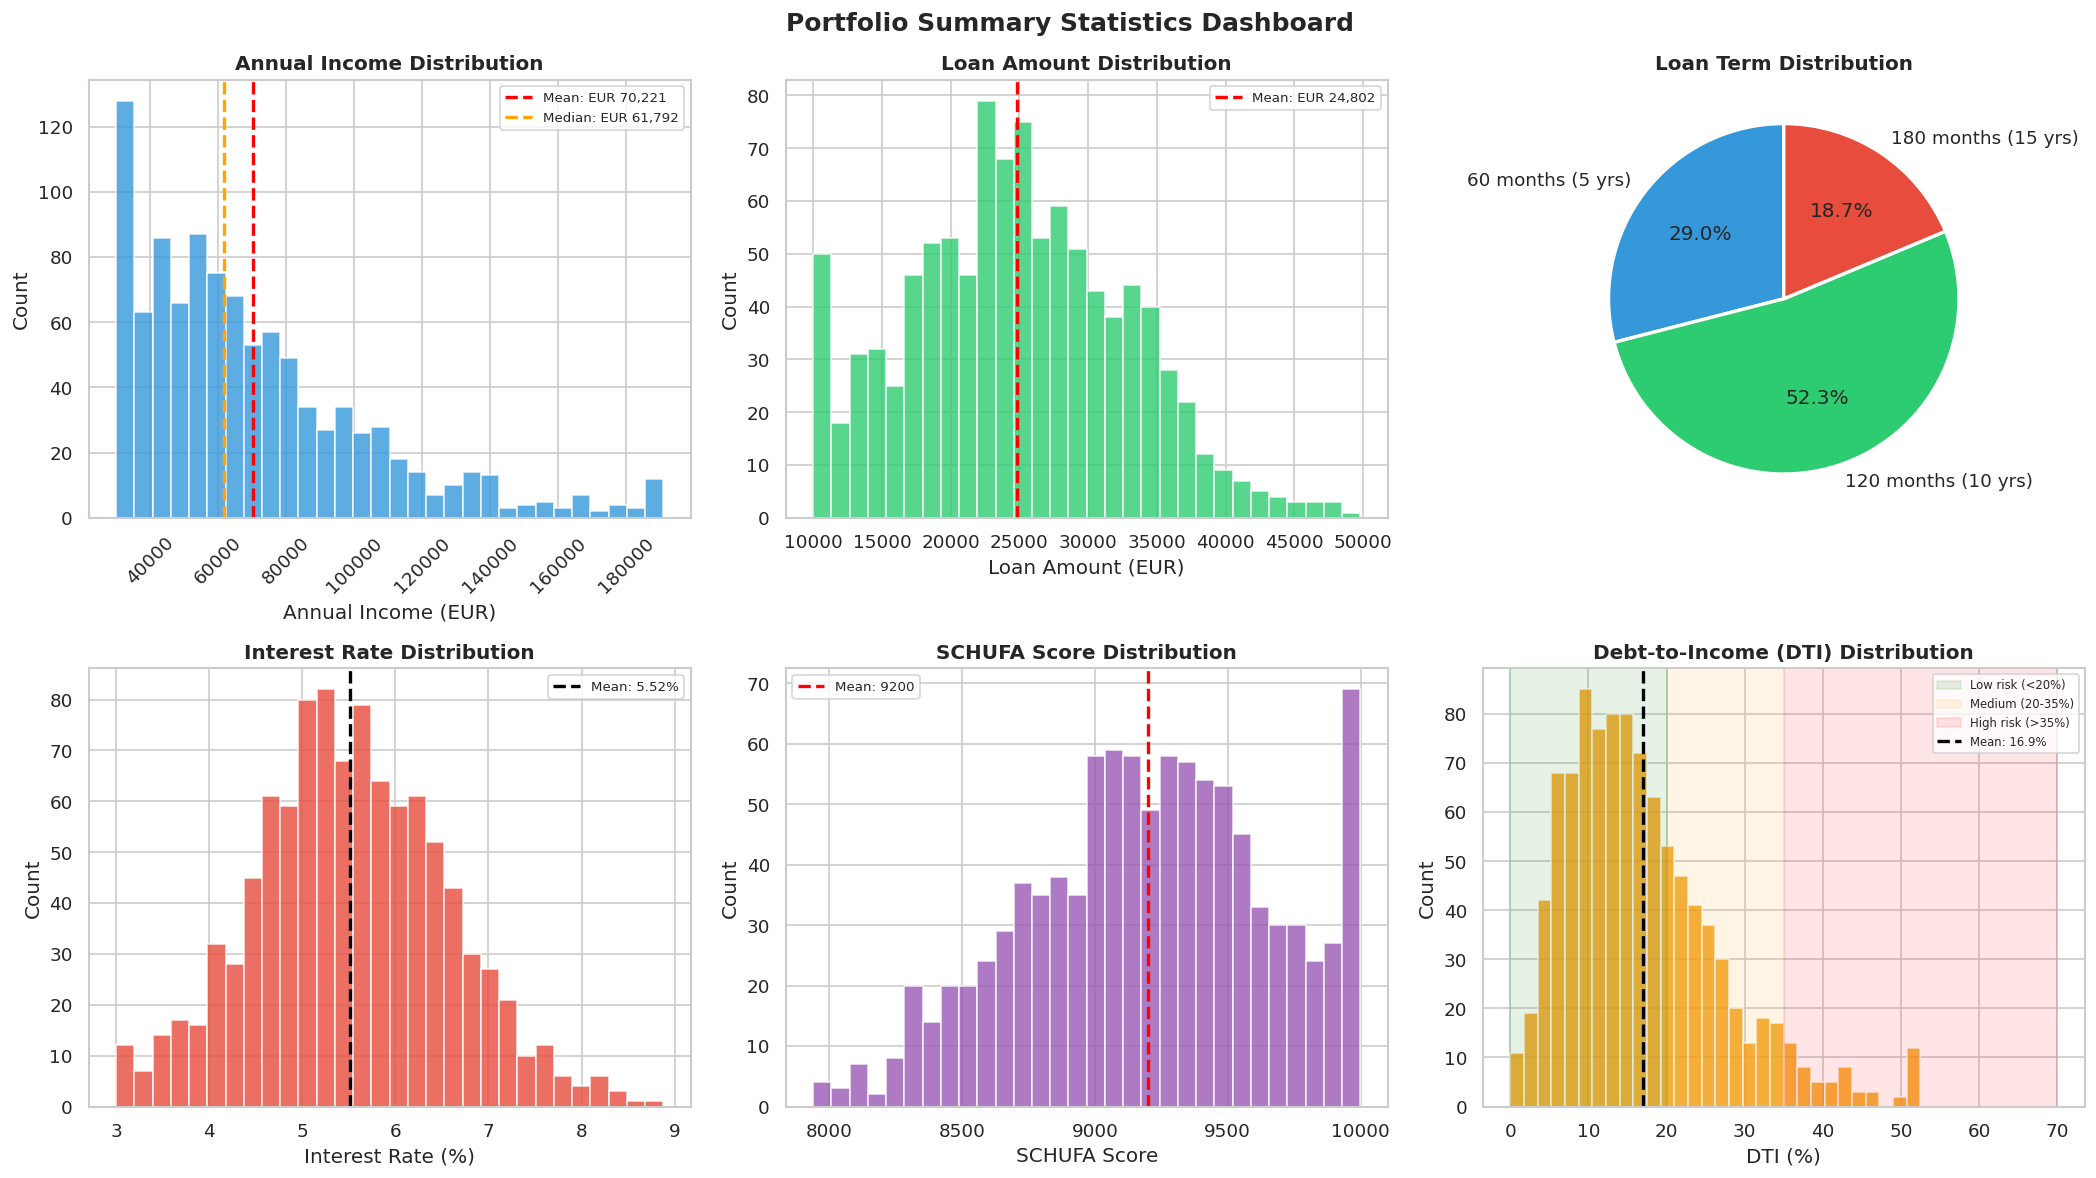

In [119]:
# Create dashboard layout
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Portfolio Summary Statistics Dashboard", fontsize=15, fontweight="bold")

# ---------------------------
# 1. Annual Income Distribution
# ---------------------------
axes[0,0].hist(df["annual_income"], bins=30, color="#3498db", edgecolor="white", alpha=0.8)

axes[0,0].axvline(
    df["annual_income"].mean(),
    color="red",
    ls="--",
    lw=2,
    label=f'Mean: EUR {df["annual_income"].mean():,.0f}'
)

axes[0,0].axvline(
    df["annual_income"].median(),
    color="orange",
    ls="--",
    lw=2,
    label=f'Median: EUR {df["annual_income"].median():,.0f}'
)

axes[0,0].set_title("Annual Income Distribution", fontweight="bold")
axes[0,0].set_xlabel("Annual Income (EUR)")
axes[0,0].set_ylabel("Count")
axes[0,0].legend(fontsize=8)
axes[0,0].tick_params(axis="x", rotation=45)

# ---------------------------
# 2. Loan Amount Distribution
# ---------------------------
axes[0,1].hist(df["loan_amount"], bins=30, color="#2ecc71", edgecolor="white", alpha=0.8)

axes[0,1].axvline(
    df["loan_amount"].mean(),
    color="red",
    ls="--",
    lw=2,
    label=f'Mean: EUR {df["loan_amount"].mean():,.0f}'
)

axes[0,1].set_title("Loan Amount Distribution", fontweight="bold")
axes[0,1].set_xlabel("Loan Amount (EUR)")
axes[0,1].set_ylabel("Count")
axes[0,1].legend(fontsize=8)

# ---------------------------
# 3. Loan Term Distribution (Pie)
# ---------------------------
term_counts = df["loan_term_months"].value_counts().sort_index()

labels = [f"{t} months ({t//12} yrs)" for t in term_counts.index]

axes[0,2].pie(
    term_counts,
    labels=labels,
    autopct="%1.1f%%",
    colors=["#3498db", "#2ecc71", "#e74c3c"],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)

axes[0,2].set_title("Loan Term Distribution", fontweight="bold")

# ---------------------------
# 4. Interest Rate Distribution
# ---------------------------
axes[1,0].hist(df["interest_rate"], bins=30, color="#e74c3c", edgecolor="white", alpha=0.8)

axes[1,0].axvline(
    df["interest_rate"].mean(),
    color="black",
    ls="--",
    lw=2,
    label=f'Mean: {df["interest_rate"].mean():.2f}%'
)

axes[1,0].set_title("Interest Rate Distribution", fontweight="bold")
axes[1,0].set_xlabel("Interest Rate (%)")
axes[1,0].set_ylabel("Count")
axes[1,0].legend(fontsize=8)

# ---------------------------
# 5. SCHUFA Score Distribution
# ---------------------------
axes[1,1].hist(df["schufa_score"], bins=30, color="#9b59b6", edgecolor="white", alpha=0.8)

axes[1,1].axvline(
    df["schufa_score"].mean(),
    color="red",
    ls="--",
    lw=2,
    label=f'Mean: {df["schufa_score"].mean():.0f}'
)

axes[1,1].set_title("SCHUFA Score Distribution", fontweight="bold")
axes[1,1].set_xlabel("SCHUFA Score")
axes[1,1].set_ylabel("Count")
axes[1,1].legend(fontsize=8)

# ---------------------------
# 6. Debt-to-Income Distribution
# ---------------------------
dti_pct = df["debt_to_income"] * 100

axes[1,2].hist(dti_pct, bins=30, color="#f39c12", edgecolor="white", alpha=0.8)

axes[1,2].axvspan(0, 20, alpha=0.1, color="green", label="Low risk (<20%)")
axes[1,2].axvspan(20, 35, alpha=0.1, color="orange", label="Medium (20-35%)")
axes[1,2].axvspan(35, 70, alpha=0.1, color="red", label="High risk (>35%)")

axes[1,2].axvline(
    dti_pct.mean(),
    color="black",
    ls="--",
    lw=2,
    label=f"Mean: {dti_pct.mean():.1f}%"
)

axes[1,2].set_title("Debt-to-Income (DTI) Distribution", fontweight="bold")
axes[1,2].set_xlabel("DTI (%)")
axes[1,2].set_ylabel("Count")
axes[1,2].legend(fontsize=7)

plt.tight_layout()
plt.show()

#  Risk Profiling

In [126]:
# SCHUFA score: higher = safer, so LOW score = more risk points
#   Above 9300  -> 0 pts (good credit)
#   8800-9300   -> 1 pt  (average)
#   Below 8800  -> 2 pts (poor credit)
df['score_schufa'] = pd.cut(df['schufa_score'],
    bins=[0, 8800, 9300, 9999], labels=[2, 1, 0]).astype(int)

# Loan amount: bigger loan = more risk points
#   Below 20K   -> 0 pts
#   20K - 35K   -> 1 pt
#   Above 35K   -> 2 pts
df['score_loan'] = pd.cut(df['loan_amount'],
    bins=[0, 20000, 35000, 999999], labels=[0, 1, 2]).astype(int)

# Annual income: lower income = more risk points
#   Above 75K   -> 0 pts (comfortable)
#   45K - 75K   -> 1 pt
#   Below 45K   -> 2 pts (tight budget)
df['score_income'] = pd.cut(df['annual_income'],
    bins=[0, 45000, 75000, 999999], labels=[2, 1, 0]).astype(int)

# Debt-to-income: higher DTI = more risk points
#   Below 15%   -> 0 pts
#   15% - 30%   -> 1 pt
#   Above 30%   -> 2 pts
df['score_dti'] = pd.cut(df['debt_to_income'],
    bins=[-1, 0.15, 0.30, 999], labels=[0, 1, 2]).astype(int)

df['score_defaults'] = df['previous_defaults'].apply(
    lambda x: 0 if x == 0 else (1 if x == 1 else 2)
)

score_cols = ['score_schufa', 'score_loan', 'score_income', 'score_dti', 'score_defaults']
print(df[score_cols].head())

   score_schufa  score_loan  score_income  score_dti  score_defaults
0             2           1             0          0               0
1             2           1             0          0               0
2             0           1             1          0               0
3             0           1             2          2               1
4             1           0             0          0               0


In [128]:
df['total_score'] = (
    df['score_schufa']   +
    df['score_loan']     +
    df['score_income']   +
    df['score_dti']      +
    df['score_defaults']
)

print('Score range:', df['total_score'].min(), 'to', df['total_score'].max())

print(df['total_score'].value_counts().sort_index().to_string())

Score range: 0 to 8
total_score
0     41
1    127
2    181
3    230
4    184
5    138
6     68
7     29
8      2


In [130]:
df['risk_category'] = pd.cut(df['total_score'],
    bins=[-1, 3, 6, 10],
    labels=['Low', 'Medium', 'High']
)

print(df['risk_category'].value_counts().reindex(['Low', 'Medium', 'High']))

risk_category
Low       579
Medium    390
High       31
Name: count, dtype: int64


In [131]:
summary = df.groupby('risk_category', observed=True).agg(
    Customers    = ('customer_id',   'count'),
    Default_Rate = ('default_flag',  lambda x: f"{x.mean()*100:.1f}%"),
    Avg_SCHUFA   = ('schufa_score',  lambda x: f"{x.mean():.0f}"),
    Avg_Income   = ('annual_income', lambda x: f"EUR {x.mean():,.0f}"),
    Avg_Loan     = ('loan_amount',   lambda x: f"EUR {x.mean():,.0f}"),
    Avg_Rate     = ('interest_rate', lambda x: f"{x.mean():.2f}%")
).reindex(['Low', 'Medium', 'High'])

print(summary.to_string())

               Customers Default_Rate Avg_SCHUFA  Avg_Income    Avg_Loan Avg_Rate
risk_category                                                                    
Low                  579         1.6%       9337  EUR 86,372  EUR 23,156    5.53%
Medium               390         4.9%       9037  EUR 48,912  EUR 26,769    5.48%
High                  31         9.7%       8687  EUR 36,638  EUR 30,805    5.69%


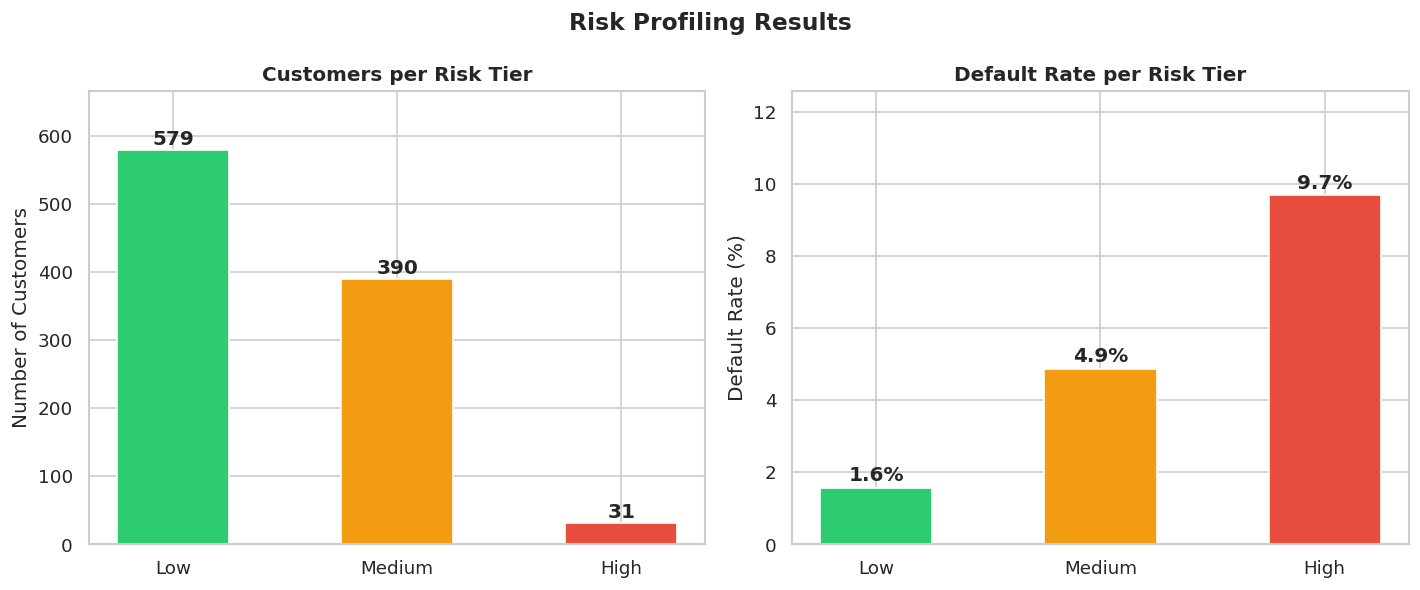

In [133]:
risk_colors = ['#2ecc71', '#f39c12', '#e74c3c']
tiers       = ['Low', 'Medium', 'High']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Risk Profiling Results', fontsize=14, fontweight='bold')

counts = df['risk_category'].value_counts().reindex(tiers)
bars   = axes[0].bar(tiers, counts, color=risk_colors, edgecolor='white', width=0.5)
axes[0].set_title('Customers per Risk Tier', fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, counts.max() * 1.15)
for bar, val in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 8,
                 str(val), ha='center', fontsize=12, fontweight='bold')

dr = df.groupby('risk_category', observed=True)['default_flag'].mean().reindex(tiers) * 100
bars2 = axes[1].bar(tiers, dr, color=risk_colors, edgecolor='white', width=0.5)
axes[1].set_title('Default Rate per Risk Tier', fontweight='bold')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_ylim(0, dr.max() * 1.3)
for bar, val in zip(bars2, dr):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.2,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

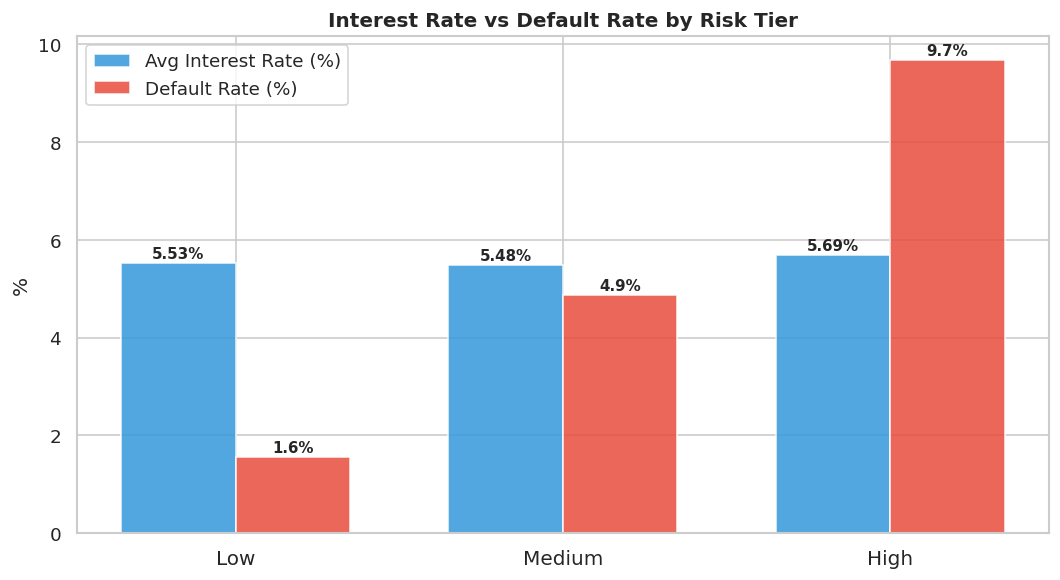

In [135]:
avg_rate = df.groupby('risk_category', observed=True)['interest_rate'].mean().reindex(tiers)
dr       = df.groupby('risk_category', observed=True)['default_flag'].mean().reindex(tiers) * 100

fig, ax = plt.subplots(figsize=(9, 5))
x     = range(len(tiers))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], avg_rate, width=width,
               color='#3498db', alpha=0.85, label='Avg Interest Rate (%)', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], dr, width=width,
               color='#e74c3c', alpha=0.85, label='Default Rate (%)', edgecolor='white')

ax.set_xticks(list(x))
ax.set_xticklabels(tiers, fontsize=12)
ax.set_ylabel('%')
ax.set_title('Interest Rate vs Default Rate by Risk Tier', fontweight='bold')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}%', ha='center', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('risk_viz2.png', bbox_inches='tight')
plt.show()


# Predictive Modeling

In [154]:
corr_with_default = df.select_dtypes(include='number').corr()['default_flag']
corr_with_default = corr_with_default.drop('default_flag')
corr_with_default = corr_with_default.sort_values(key=abs, ascending=False)

for feat, val in corr_with_default.head(33).items():
    sign = '+' if val > 0 else '-'
    print(f'{feat:30s} {sign}{abs(val):.4f}')

default_probability            +0.9943
late_payments_90               +0.4778
score_schufa                   +0.2125
schufa_score                   -0.2076
total_score                    +0.1391
previous_defaults              +0.0634
score_defaults                 +0.0634
estimated_annual_production    +0.0490
employment_years               +0.0400
age                            +0.0393
credit_utilization             -0.0374
score_income                   +0.0349
income_to_loan_ratio           -0.0333
annual_income                  -0.0327
max_days_late                  -0.0299
score_dti                      +0.0279
loan_term_months               +0.0270
avg_days_late                  -0.0245
interest_rate                  +0.0220
loan_to_income_ratio           +0.0147
current_monthly_debt           -0.0144
customer_id                    +0.0142
installation_cost              +0.0133
monthly_payment                -0.0123
avg_payment                    -0.0120
debt_to_income           

In [136]:
FEATURES = [
    'schufa_score',
    'loan_amount',
    'income_to_loan_ratio',
    'annual_income',
    'debt_to_income',
    'credit_utilization',
    'previous_defaults',
    'late_payments_30',
    'late_payments_90',
]

X = df[FEATURES]
y = df['default_flag']

print('Input shape :', X.shape)
print('Defaults    :', y.sum(), 'out of', len(y), f'({y.mean()*100:.1f}%)')

Input shape : (1000, 9)
Defaults    : 31 out of 1000 (3.1%)


In [137]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Training customers:', len(X_train), '| Defaults in train:', y_train.sum())
print('Testing  customers:', len(X_test),  '| Defaults in test :', y_test.sum())

Training customers: 800 | Defaults in train: 25
Testing  customers: 200 | Defaults in test : 6


In [152]:
models = {
    'Logistic Regression': Pipeline([
        ('model', LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000))
    ]),
    'Random Forest': Pipeline([
        ('model', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
    ])
}

results = {}
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results[name] = {
        'pipeline': pipeline,
        'y_pred':   y_pred,
        'y_prob':   y_prob,
        'accuracy': accuracy_score(y_test, y_pred),
        'auc':      roc_auc_score(y_test, y_prob)
    }
    print(f'{name:22s}  Accuracy: {results[name]["accuracy"]*100:.1f}%   AUC: {results[name]["auc"]:.3f}')

Logistic Regression     Accuracy: 94.0%   AUC: 0.998
Random Forest           Accuracy: 100.0%   AUC: 1.000


In [163]:
best_pipeline = results['Random Forest']['pipeline']
df['default_probability'] = best_pipeline.predict_proba(X)[:, 1]

sample = df[['schufa_score', 'loan_amount', 'annual_income','income_to_loan_ratio',
              'default_flag', 'default_probability']].sample(20, random_state=5)
sample['default_probability'] = (sample['default_probability'] * 100).round(1).astype(str) + '%'
sample.columns = ['SCHUFA', 'Loan (EUR)', 'Income (EUR)','income_to_loan_ratio', 'Actual Default', 'Predicted PD']

print(sample.to_string())


     SCHUFA  Loan (EUR)  Income (EUR)  income_to_loan_ratio  Actual Default Predicted PD
544    9999       23344       44306.0              1.897961               0         0.0%
515    9465       22335       56338.0              2.522409               0         0.0%
193    8338       13761       70255.0              5.105370               0         0.0%
11     9385       33184       66091.0              1.991653               0         0.0%
279    8612       20476       51299.0              2.505323               0         0.0%
653    8860       40038       50182.0              1.253359               0         0.0%
643    9532       14563       75070.0              5.154844               0         0.0%
763    9598       22691       30000.0              1.322110               0         0.0%
198    9127       26640       66967.0              2.513776               0         0.0%
721    8585       36734       52587.0              1.431562               0         1.0%
236    9309       100